# Análisis Diagnóstico: Análisis de Tendencias de Contrataciones Públicas

### Carga de las librerías de Python necesarias

In [21]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import seaborn as sns
from scipy.stats import linregress

### Conexión a SQL Server y extracción de los datos

In [28]:
# Configuración de gráficos
plt.rcParams['figure.figsize'] = [12, 8]
pd.options.display.float_format = '{:.2f}'.format

# Crear el engine de SQLAlchemy con pyodbc
conn_str = (
    "mssql+pyodbc://DESKTOP-N55HPMR/I_DE_NEGOCIOS_BD_NUEVO"
    "?driver=ODBC+Driver+17+for+SQL+Server"  # Asegúrate de que esté instalado
    "&trusted_connection=yes"
)
engine = create_engine(conn_str)

# Consulta SQL
query = '''
SELECT 
    YEAR(h.fecha_buenapro) as año,
    MONTH(h.fecha_buenapro) as mes,
    SUM(h.monto_adjudicado_item) as monto_adjudicado,
    COUNT(h.id_hecho) as cantidad_contratos
FROM hechos_contrataciones h
WHERE h.fecha_buenapro IS NOT NULL
GROUP BY YEAR(h.fecha_buenapro), MONTH(h.fecha_buenapro)
ORDER BY año, mes
'''

# Ejecutar consulta
contrataciones = pd.read_sql(query, engine)

## Exploración del dataset extraído

### Exploración inicial de los datos

In [26]:
# Ver las primeras filas
print(contrataciones.head())

# Dimensiones del dataset
print("\nDimensiones del dataset:", contrataciones.shape)

# Columnas disponibles
print("\nColumnas:", contrataciones.columns)

    año  mes  monto_adjudicado  cantidad_contratos
0  2020    1      105431240.86                 142
1  2020    2        6206189.17                   4
2  2020    3       20103259.05                  26
3  2020    4       26852199.60                  30
4  2020    5       13965760.96                   9

Dimensiones del dataset: (53, 4)

Columnas: Index(['año', 'mes', 'monto_adjudicado', 'cantidad_contratos'], dtype='object')


## Visualización gráfica de los datos

#### Gráfico de barras de montos adjudicados por mes

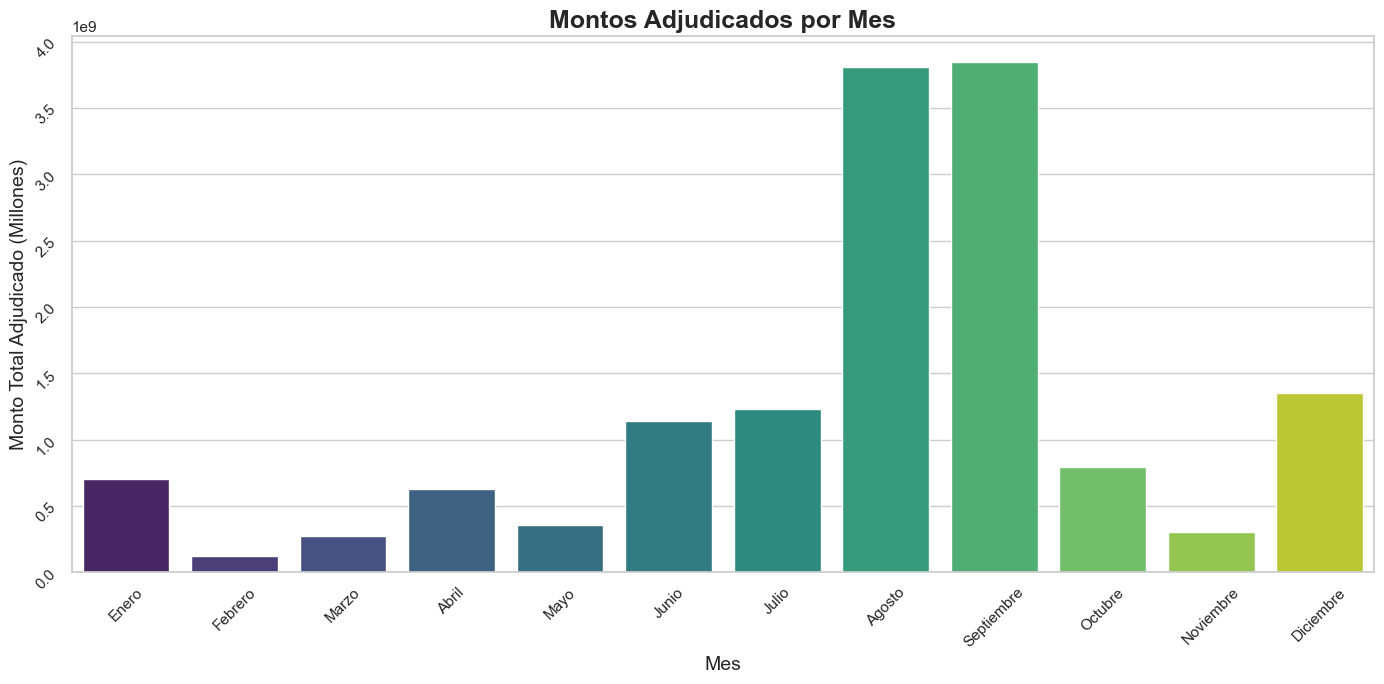

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
import locale

# Establecer la localización en español
locale.setlocale(locale.LC_TIME, 'es_ES.UTF-8')  # En sistemas Unix/Linux/Mac
# En Windows, puede que necesites usar: locale.setlocale(locale.LC_TIME, 'Spanish_Spain')

# Crear lista con los nombres de los meses en español
meses_orden = [calendar.month_name[i].capitalize() for i in range(1, 13)]

# Asegurate que tu columna 'mes' tenga números del 1 al 12
# Crear la columna con nombres de meses en español
contrataciones['mes_nombre'] = contrataciones['mes'].apply(lambda x: calendar.month_name[x].capitalize())

# Agrupar por mes con nombres en español
monto_por_mes = contrataciones.groupby('mes_nombre')['monto_adjudicado'].sum().reset_index()

# Convertir a categórico para mantener orden
monto_por_mes['mes_nombre'] = pd.Categorical(
    monto_por_mes['mes_nombre'], categories=meses_orden, ordered=True
)

# Ordenar el DataFrame
monto_por_mes = monto_por_mes.sort_values('mes_nombre')

# Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Elegir una paleta moderna
colores = sns.color_palette("viridis", len(monto_por_mes))

# Crear la gráfica
ax = sns.barplot(
    x='mes_nombre',
    y='monto_adjudicado',
    hue='mes_nombre',  # Asignar hue
    data=monto_por_mes,
    palette=colores,
    legend=False       # Desactivar leyenda redundante
)
ax.set_title('Montos Adjudicados por Mes', fontsize=18, fontweight='bold')
ax.set_xlabel('Mes', fontsize=14)
ax.set_ylabel('Monto Total Adjudicado (Millones)', fontsize=14)
ax.tick_params(labelrotation=45)

plt.tight_layout()
plt.show()

#### Gráfico de línea de montos adjudicados por año

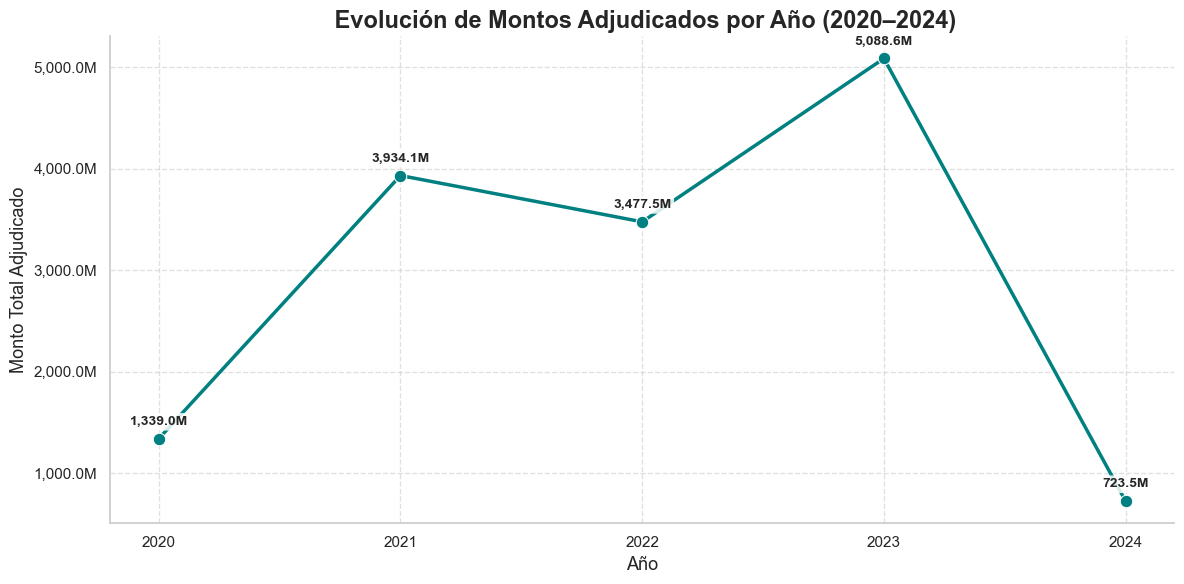

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo elegante
sns.set_theme(style="whitegrid")

# Agregación por año
monto_por_año = contrataciones.groupby('año')['monto_adjudicado'].sum().reset_index()
monto_por_año = monto_por_año[monto_por_año['año'].between(2020, 2024)]

# Crear figura
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x='año',
    y='monto_adjudicado',
    data=monto_por_año,
    marker='o',
    linewidth=2.5,
    markersize=9,
    color='#008080'
)

# Formatear eje Y en millones con separador de miles
formatter = FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Etiquetas de valor por punto (con desplazamiento y sombra)
for i, row in monto_por_año.iterrows():
    ax.annotate(
        f"{row['monto_adjudicado'] / 1e6:,.1f}M",
        xy=(row['año'], row['monto_adjudicado']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.85)
    )

# Títulos y ejes
ax.set_title(' Evolución de Montos Adjudicados por Año (2020–2024)', fontsize=17, fontweight='bold')
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('Monto Total Adjudicado', fontsize=13)
ax.set_xticks(range(2020, 2025))
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### Gráfico de cantidad de contratos por año

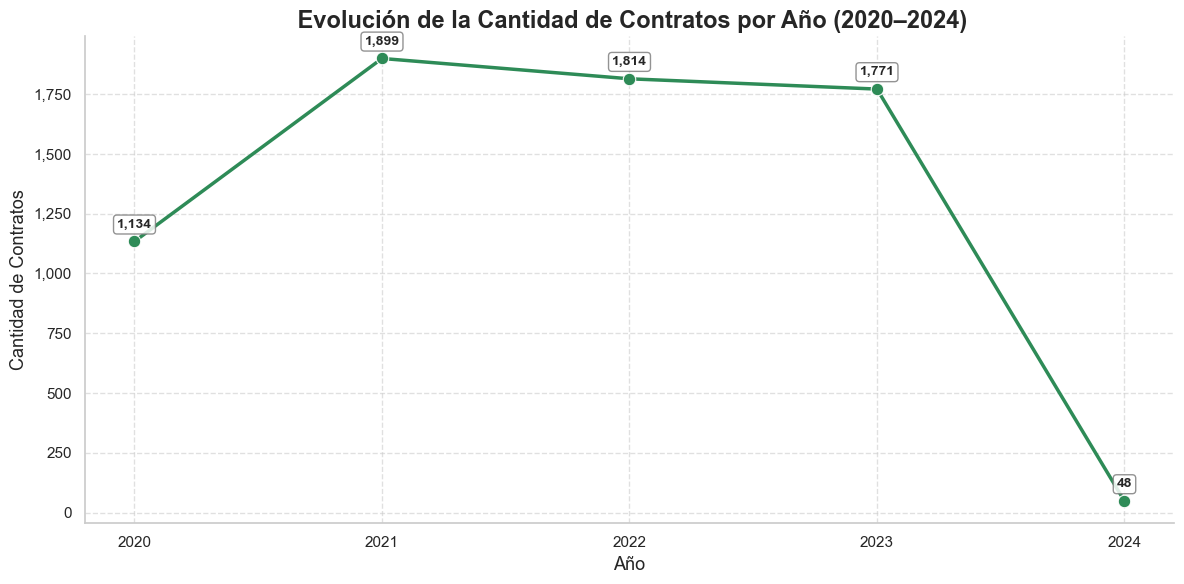

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Estilo visual
sns.set_theme(style="whitegrid")

# Agrupación por año
contratos_por_año = contrataciones.groupby('año')['cantidad_contratos'].sum().reset_index()
contratos_por_año = contratos_por_año[contratos_por_año['año'].between(2020, 2024)]

# Figura
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    x='año',
    y='cantidad_contratos',
    data=contratos_por_año,
    marker='o',
    linewidth=2.5,
    markersize=9,
    color='#2E8B57'  # Verde más elegante
)

# Formateo del eje Y con separador de miles
formatter = FuncFormatter(lambda x, _: f'{x:,.0f}')
ax.yaxis.set_major_formatter(formatter)

# Añadir etiquetas encima de los puntos
for i, row in contratos_por_año.iterrows():
    ax.annotate(
        f"{int(row['cantidad_contratos']):,}",
        xy=(row['año'], row['cantidad_contratos']),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.85)
    )

# Ajustes estéticos
ax.set_title(' Evolución de la Cantidad de Contratos por Año (2020–2024)', fontsize=17, fontweight='bold')
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('Cantidad de Contratos', fontsize=13)
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xticks(range(2020, 2025))

plt.tight_layout()
plt.show()

## Análisis de tendencia formal

#### Para montos adjudicados

In [46]:
# Análisis de tendencia lineal
slope, intercept, r_value, p_value, std_err = linregress(
    contrataciones['año'],
    contrataciones['monto_adjudicado']
)

# Mostrar resultados con claridad
print("\n Análisis de Tendencia para Montos Adjudicados:")
print(f" Pendiente: {slope:,.2f}")
print(f" R²: {r_value**2:.4f}")
print(f" Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print(" Existe una tendencia significativa en los montos adjudicados a lo largo del tiempo.")
else:
    print(" No hay evidencia estadísticamente significativa de una tendencia en los montos adjudicados.")


 Análisis de Tendencia para Montos Adjudicados:
 Pendiente: 42,695,461.18
 R²: 0.0153
 Valor p: 0.3776
 No hay evidencia estadísticamente significativa de una tendencia en los montos adjudicados.


#### Para cantidad de contratos

In [50]:
from scipy.stats import linregress

# Análisis de tendencia en cantidad de contratos
slope, intercept, r_value, p_value, std_err = linregress(
    contrataciones['año'],
    contrataciones['cantidad_contratos']
)

print("\n📈 Análisis de Tendencia para Cantidad de Contratos:")
print(f"🔹 Pendiente: {slope:,.0f} contratos/año")
print(f"🔹 R²: {r_value**2:.4f}")
print(f"🔹 Valor p: {p_value:.4f}")

if p_value < 0.05:
    print(" Existe una tendencia estadísticamente significativa en la cantidad de contratos.")
    tendencia = "positiva" if slope > 0 else "negativa"
    print(f" Dirección de la tendencia: {tendencia.capitalize()}")
else:
    print("⚠️ No hay evidencia estadísticamente significativa de una tendencia en la cantidad de contratos.")


📈 Análisis de Tendencia para Cantidad de Contratos:
🔹 Pendiente: -6 contratos/año
🔹 R²: 0.0050
🔹 Valor p: 0.6157
⚠️ No hay evidencia estadísticamente significativa de una tendencia en la cantidad de contratos.


## Análisis adicional por departamento

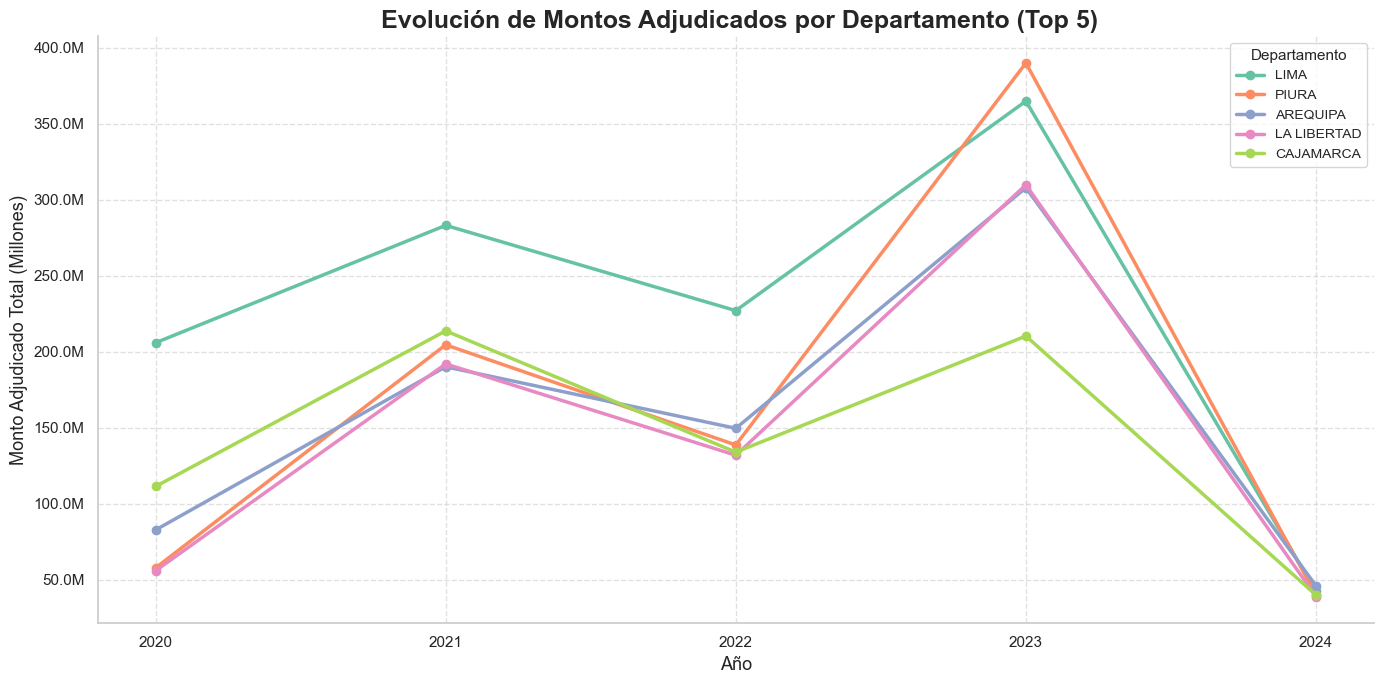

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Agrupar datos por año y filtrar top 5 departamentos
top_dept = (
    contrataciones_dept.groupby('departamento')['monto_adjudicado']
    .sum()
    .nlargest(5)
    .index
)

contrataciones_top = contrataciones_dept[
    contrataciones_dept['departamento'].isin(top_dept)
]

# Configurar estilo visual
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set2", n_colors=5)

plt.figure(figsize=(14, 7))
ax = plt.gca()

# Trazar líneas para cada departamento
for i, dept in enumerate(top_dept):
    dept_data = contrataciones_top[contrataciones_top['departamento'] == dept]
    ax.plot(
        dept_data['año'],
        dept_data['monto_adjudicado'],
        marker='o',
        linewidth=2.5,
        label=dept,
        color=palette[i]
    )

# Formato del eje Y en millones con separador de miles
formatter = FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M')
ax.yaxis.set_major_formatter(formatter)

# Título y etiquetas
ax.set_title(' Evolución de Montos Adjudicados por Departamento (Top 5)', fontsize=18, fontweight='bold')
ax.set_xlabel('Año', fontsize=13)
ax.set_ylabel('Monto Adjudicado Total (Millones)', fontsize=13)
ax.tick_params(labelsize=11)
ax.set_xticks(sorted(contrataciones_top['año'].unique()))
ax.legend(title='Departamento', fontsize=10, title_fontsize=11, frameon=True)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Conclusiones

No existe una tendencia estadísticamente significativa en montos o cantidad de contratos, pero sí hay fluctuaciones importantes que merecen atención. El análisis sugiere que los cambios responden más a factores coyunturales (como proyectos puntuales o ajustes presupuestarios) que a una tendencia estructural.

#### Hallazgos Principales
1. Volatilidad en Montos Adjudicados
   
* Se observó un crecimiento excepcional en 2021 (3,934.1M, +195% vs. 2020), seguido de una caída abrupta en 2023 (723.5M, -79% vs. 2022).
* Aunque la pendiente sugiere un aumento promedio de 42.7M/año, el valor p (0.3776) y R² bajo (0.0153) indican que no hay una tendencia estadísticamente significativa.

2. Estabilidad en la Cantidad de Contratos

* La cantidad de contratos se mantuvo relativamente estable (~1,800 contratos/año), con una ligera tendencia a la baja (-6 contratos/año).
* Sin embargo, el valor p (0.6157) y R² casi nulo (0.0050) confirman que no hay una tendencia clara.